# 00 — Run all: explore + SFT + GRPO + eval (single notebook)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sneh2909/Overfitters/blob/main/notebooks/00_run_all.ipynb)
[![HF Space](https://img.shields.io/badge/🤗_Space-SnehShah/house--md--env-yellow)](https://huggingface.co/spaces/SnehShah/house-md-env)
[![OpenEnv UI](https://img.shields.io/badge/🤗_OpenEnv_UI-SnehShah/house--md--env--openenv-yellow)](https://huggingface.co/spaces/SnehShah/house-md-env-openenv)

Single notebook that walks the **entire House M.D. pipeline** end-to-end:

1. Connect to the live OpenEnv Space.
2. Explore the action / observation schema.
3. Run a manual episode, a random episode, and an oracle episode.
4. Test the standard **OpenEnv UI** Space with copy-paste action JSON.
5. Plot the frozen base / SFT / GRPO eval comparison.
6. *(optional, GPU)* Mini SFT warm-start on Gemma 3 4B-IT (~12 min on T4) — Colab-tuned reduction of [`scripts/train_sft.py`](https://github.com/sneh2909/Overfitters/blob/main/scripts/train_sft.py).
7. *(optional, GPU)* Mini GRPO loop using a **local in-process** `ClinicalEnv` (~15 min on T4) — Colab-tuned reduction of [`scripts/train_grpo_optimized.py`](https://github.com/sneh2909/Overfitters/blob/main/scripts/train_grpo_optimized.py). No HTTP latency, identical reward computation as the canonical L4/A100 jobs.
8. *(optional, GPU)* Mini-eval of any LoRA adapter against the local env using the held-out `eval_set.jsonl` patient seeds (matches `scripts/eval_hf.py`).

Sections **1-5** run on a free Colab CPU runtime in ~3 minutes. Sections **6-8** require a GPU and are individually skippable.

## 1. Install dependencies

Always-needed: HF Hub + OpenEnv client + the env package (which carries `HouseMDEnv` / `HouseMDAction`).

GPU dependencies (Unsloth / TRL / PEFT) are installed lazily inside the optional sections so CPU-only runs don't pay for them.

In [1]:
%%capture
!pip install -q "openenv-core>=0.2.2" requests pydantic pandas matplotlib huggingface_hub
!pip install -q "git+https://github.com/sneh2909/Overfitters.git#subdirectory=house_md_env"

## 2. Authenticate (HF + W&B optional)

Set `HF_TOKEN` (and optionally `WANDB_API_KEY`) in **Colab Secrets** so they don't leak into the notebook output. CPU-only sections work without any token.

In [5]:
import os

try:
    from google.colab import userdata
    os.environ["HF_TOKEN"]      = userdata.get("HF_TOKEN")      or os.environ.get("HF_TOKEN", "")
    os.environ["HF_USERNAME"]   = userdata.get("HF_USERNAME")   or os.environ.get("HF_USERNAME", "")
    os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY") or os.environ.get("WANDB_API_KEY", "")
except Exception:
    pass

# Set HF_TOKEN / HF_USERNAME / WANDB_API_KEY in Colab Secrets (or as env vars
# locally) — never paste them into the notebook itself. Hugging Face will
# refuse Space pushes that contain a real token in any committed file.
HF_USERNAME   = os.environ.get("HF_USERNAME", "")
HF_TOKEN      = os.environ.get("HF_TOKEN", "")
WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "")

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN
    print("✓ HF token set (skipping whoami to avoid /whoami-v2 rate-limit)")
else:
    print("⚠  HF_TOKEN missing — push steps will be skipped")

if WANDB_API_KEY:
    import wandb
    wandb.login(key=WANDB_API_KEY, relogin=True)
    print("✓ logged into W&B")
else:
    print("⚠  WANDB_API_KEY missing — metrics won't be uploaded")

✓ logged into HF
⚠  WANDB_API_KEY missing — metrics won't be uploaded


## 3. Connect to the live OpenEnv Space

`HouseMDEnv` is a thin OpenEnv `EnvClient`. We point it at the Space's public URL and call `.sync()` to open a session.

- **Custom ER scene:** <https://snehshah-house-md-env.hf.space/>
- **Standard OpenEnv UI:** <https://snehshah-house-md-env-openenv.hf.space/web/>

Both run the same FastAPI server, so we can use either as the training backend.

In [6]:
from house_md_env import HouseMDEnv, HouseMDAction, HouseMDActionType, HouseMDObservation

ENV_URL = "https://snehshah-house-md-env.hf.space"
OPENENV_UI_URL = "https://snehshah-house-md-env-openenv.hf.space"
API = ENV_URL + "/api"

env = HouseMDEnv(base_url=ENV_URL).sync()
print("connected to:", ENV_URL)

connected to: https://snehshah-house-md-env.hf.space


## 4. Inspect the action / observation schema

Five action verbs with closed vocabularies:

| `type` | `argument` | typical cost | latency |
| --- | --- | --- | --- |
| `INTERVIEW` | 25 question ids | $0 | 1 step |
| `EXAMINE` | 15 exam ids | low | 1 step |
| `ORDER_TEST` | 35 lab/imaging ids | $5 – $1500 | 1–3 steps (delayed) |
| `UPDATE_DIFFERENTIAL` | free-text + `board=[{disease, prob}, ...]` | $0 | instant |
| `DIAGNOSE` | 35 disease ids | $0 | terminal |

In [7]:
import json

print("ActionType options:")
for at in HouseMDActionType:
    print(f"  - {at.value}")

schema = HouseMDAction.model_json_schema()
print("\nHouseMDAction schema (truncated):")
print(json.dumps(schema, indent=2)[:600] + "\n  ...")

ActionType options:
  - INTERVIEW
  - EXAMINE
  - ORDER_TEST
  - UPDATE_DIFFERENTIAL
  - DIAGNOSE

HouseMDAction schema (truncated):
{
  "$defs": {
    "HouseMDActionType": {
      "enum": [
        "INTERVIEW",
        "EXAMINE",
        "ORDER_TEST",
        "UPDATE_DIFFERENTIAL",
        "DIAGNOSE"
      ],
      "title": "HouseMDActionType",
      "type": "string"
    }
  },
  "additionalProperties": false,
  "description": "One action emitted by the diagnostician agent.\n\nThe five legal action types are detailed in `clinical_rl.env.state.ActionType`.\n`argument` is interpreted differently depending on `type`:\n\n  * INTERVIEW            -> question id (e.g. \"lmp\")\n  * EXAMINE              -> exam id (e.g. \"abdomin
  ...


## 5. Reset to a new patient and read the intake

The Space samples a disease + variant + RNG seed and returns a noisy intake. The agent has to dig for the rest.

In [8]:
result = env.reset()
obs: HouseMDObservation = result.observation

print("=== ENV STATE ===")
print(f"Step            : {obs.step} / {obs.step_cap}")
print(f"Time elapsed    : {obs.time_elapsed_min} min")
print(f"Cost so far ($) : {obs.cost_so_far}")

print("\n--- PATIENT ---")
print(f"Chief complaint : {obs.chief_complaint}")
print(f"Severity signal : {obs.severity_signal}")
print(f"Vitals          : {obs.intake_vitals}")

print("\n--- BOOKKEEPING ---")
print(f"Pending tests   : {obs.pending_tests}")
print(f"Differential    : {obs.differential_board}")
print(f"Actions logged  : {len(obs.action_log)}")

print("\n--- TERMINAL ---")
print(f"Terminal        : {obs.terminal}")
print(f"Diagnosis       : {obs.diagnosis}")
print(f"Timed out       : {obs.timed_out}")

=== ENV STATE ===
Step            : 1 / 15
Time elapsed    : 0 min
Cost so far ($) : 0

--- PATIENT ---
Chief complaint : excessive thirst and frequent urination
Severity signal : stable
Vitals          : HR 115, BP 100/65, RR 26, Temp 37.2°C, SpO2 98%

--- BOOKKEEPING ---
Pending tests   : []
Differential    : []
Actions logged  : 0

--- TERMINAL ---
Terminal        : False
Diagnosis       : None
Timed out       : False


## 6. Manual step — ask one question

We send `INTERVIEW(pain_onset)` and read the resulting log entry. The `LogEntryModel` fields are: `step`, `kind` (`'action'` or `'result'`), `type`, `argument`, `rationale`, `text`, `cost`, `time_min`.

In [9]:
step_result = env.step(HouseMDAction(
    type=HouseMDActionType.INTERVIEW,
    argument="pain_onset",
    rationale="narrow acute vs chronic differentials",
))
obs = step_result.observation
last = obs.action_log[-1]

print(f"kind        : {last.kind}")
print(f"type        : {last.type}")
print(f"argument    : {last.argument}")
print(f"text        : {last.text}")
print(f"cost        : ${last.cost}")
print(f"time_min    : {last.time_min}")
print(f"reward      : {step_result.reward}")
print(f"cost so far : ${obs.cost_so_far}")

kind        : action
type        : INTERVIEW
argument    : pain_onset
text        : Q (pain_onset): When did this start? Was it sudden or gradual?
A: N/A, no pain.
cost        : $0
time_min    : 1
reward      : None
cost so far : $0


## 7. Random-policy rollout (floor baseline)

Quick demonstration of the API contract. The full 45-patient eval is in `results/eval_results.json`.

In [10]:
import random

ARG_MENU = {
    HouseMDActionType.INTERVIEW: [
        "pain_onset", "pain_location", "pain_character", "nausea_vomiting", "fever_chills",
    ],
    HouseMDActionType.EXAMINE: [
        "vital_signs", "general_appearance", "abdominal_palpation", "cardiac_auscultation",
    ],
    HouseMDActionType.ORDER_TEST: [
        "cbc", "bmp", "urinalysis", "chest_xray",
    ],
}
DIAGNOSIS_GUESSES = [
    "appendicitis", "stemi", "migraine", "viral_uri", "pneumonia", "viral_gastroenteritis",
]

env.reset()
for _ in range(8):
    at = random.choice(list(ARG_MENU.keys()))
    arg = random.choice(ARG_MENU[at])
    res = env.step(HouseMDAction(type=at, argument=arg, rationale="random policy"))
    if res.observation.terminal:
        break

if not res.observation.terminal:
    res = env.step(HouseMDAction(
        type=HouseMDActionType.DIAGNOSE,
        argument=random.choice(DIAGNOSIS_GUESSES),
        rationale="random commit",
    ))

final = res.observation
print(f"steps used    : {final.step}")
print(f"cost ($)      : {final.cost_so_far}")
print(f"diagnosis     : {final.diagnosis}")
print(f"timed_out     : {final.timed_out}")
print(f"total reward  : {res.reward}")
print(f"per-rubric    : {final.rewards}")

steps used    : 9
cost ($)      : 100
diagnosis     : viral_gastroenteritis
timed_out     : False
total reward  : 0.30000000000000004
per-rubric    : {'r1_accuracy': 0.0, 'r2_cost': 0.6000000000000001, 'r6_anchoring': 0.0, 'r7_safety': -0.5, 'r8_format': 1.0, 'total': 0.30000000000000004}


## 8. Oracle episode via the session API

The Space exposes a session-based `/api/episodes/.../agent_step?policy=oracle` endpoint that uses the in-repo `HeuristicOracle` (knows the truth). It serves as a sensible upper bound.

In [19]:
import requests

session = requests.post(
    f"{API}/episodes",
    json={"disease": "appendicitis", "variant_id": "v1", "seed": 42, "policy": "oracle"},
).json()
sid = session["session_id"]
print(f"oracle session: {sid}  disease=appendicitis")

for _ in range(session.get("step_cap", 15)):
    r = requests.post(f"{API}/episodes/{sid}/agent_step").json()
    if r.get("terminal"):
        break

rewards = requests.get(f"{API}/episodes/{sid}/rewards").json()
truth = requests.get(f"{API}/episodes/{sid}/truth").json()
print(f"\nground truth disease : {truth.get('true_disease_name')}  (id={truth.get('true_disease_id')})")
print(f"oracle final guess   : {r.get('diagnosis')}  (terminal={r.get('terminal')}, steps={r.get('step')})")
print(f"oracle rewards       : {rewards}")
requests.delete(f"{API}/episodes/{sid}")

oracle session: 2d951dedeecb  disease=appendicitis

ground truth disease : Acute appendicitis  (id=appendicitis)
oracle final guess   : appendicitis  (terminal=True, steps=9)
oracle rewards       : {'r1_accuracy': 1.0, 'r2_cost': 1.0, 'r6_anchoring': 0.6, 'r7_safety': -0.2, 'r8_format': 1.0, 'total': 2.98}


<Response [200]>

## 9. Test the standard OpenEnv UI Space

Open <https://snehshah-house-md-env-openenv.hf.space/web/>, click **Reset**, then send any of the action JSONs printed below as a **Step**. The same JSON works through the OpenEnv `HouseMDAction` model in Python.

In [13]:
import requests, json

openenv_health = requests.get(f"{OPENENV_UI_URL}/health", timeout=15).json()
print("OpenEnv UI health:", openenv_health)

examples = [
    {"type": "INTERVIEW", "argument": "pain_location", "rationale": "localize the complaint"},
    {"type": "EXAMINE", "argument": "general_appearance", "rationale": "quick global assessment"},
    {"type": "ORDER_TEST", "argument": "cbc", "rationale": "screen for infection or anemia"},
    {"type": "ORDER_TEST", "argument": "urinalysis", "rationale": "cheap same-step urinary screen"},
    {
        "type": "UPDATE_DIFFERENTIAL",
        "argument": "working differential after first pass",
        "rationale": "rank likely causes before committing",
        "board": [
            {"disease": "appendicitis", "prob": 0.45},
            {"disease": "ectopic_pregnancy", "prob": 0.35},
            {"disease": "viral_gastroenteritis", "prob": 0.20},
        ],
    },
    {"type": "DIAGNOSE", "argument": "appendicitis", "rationale": "commit to leading dx"},
]
for ex in examples:
    print(json.dumps(ex))

OpenEnv UI health: {'status': 'healthy'}
{"type": "INTERVIEW", "argument": "pain_location", "rationale": "localize the complaint"}
{"type": "EXAMINE", "argument": "general_appearance", "rationale": "quick global assessment"}
{"type": "ORDER_TEST", "argument": "cbc", "rationale": "screen for infection or anemia"}
{"type": "ORDER_TEST", "argument": "urinalysis", "rationale": "cheap same-step urinary screen"}
{"type": "UPDATE_DIFFERENTIAL", "argument": "working differential after first pass", "rationale": "rank likely causes before committing", "board": [{"disease": "appendicitis", "prob": 0.45}, {"disease": "ectopic_pregnancy", "prob": 0.35}, {"disease": "viral_gastroenteritis", "prob": 0.2}]}
{"type": "DIAGNOSE", "argument": "appendicitis", "rationale": "commit to leading dx"}


## 10. Eval comparison plot (frozen results, no GPU)

Pull pre-computed eval JSONs and produce the standard accuracy / total-reward / cost plot. If you don't have access to the private results dataset, the cell prints what it found and skips silently.

In [14]:
from pathlib import Path
import json, statistics

RESULTS_REPO = f"{HF_USERNAME}/house-md-results"
TAGS = ["base", "sft", "grpo", "gemini_flash"]
summaries = {}

from huggingface_hub import hf_hub_download
for tag in TAGS:
    fname = f"eval_{tag}.json" if tag != "gemini_flash" else "gemini_flash.json"
    payload = None
    src = ""
    local = Path("results") / fname
    if local.exists():
        payload = json.loads(local.read_text())
        src = f"local: {local}"
    else:
        try:
            p = hf_hub_download(RESULTS_REPO, fname, repo_type="dataset", token=HF_TOKEN or None)
            payload = json.loads(Path(p).read_text())
            src = f"hub: {RESULTS_REPO}/{fname}"
        except Exception as e:
            src = f"missing ({type(e).__name__})"
    if payload:
        summaries[tag] = payload["summary"]
        print(f"✓ {tag:<14} acc {payload['summary']['correct_pct']}%  ({src})")
    else:
        print(f"· {tag:<14} {src}")

p = Path("results/eval_results.json")
if p.exists():
    raw = json.loads(p.read_text())
    keys = ["r1_accuracy", "r2_cost", "r6_anchoring", "r7_safety", "r8_format", "total"]
    def reduce_baseline(rows):
        n = len(rows)
        if not n:
            return None
        return {
            "n_evaluated": n,
            "correct": sum(1 for r in rows if r["correct"]),
            "correct_pct": round(100 * sum(1 for r in rows if r["correct"]) / n, 1),
            "avg_rewards": {k: round(statistics.mean(r["rewards"][k] for r in rows), 4) for k in keys},
            "avg_steps": round(statistics.mean(r["steps"] for r in rows), 1),
            "avg_cost": round(statistics.mean(r["cost"] for r in rows), 1),
        }
    for k in ("random", "greedy"):
        if isinstance(raw.get(k), list):
            summaries[k] = reduce_baseline(raw[k])
            print(f"✓ {k:<14} acc {summaries[k]['correct_pct']}%")

✓ base           acc 17.8%  (hub: SnehShah/house-md-results/eval_base.json)
· sft            missing (RemoteEntryNotFoundError)
· grpo           missing (RemoteEntryNotFoundError)
✓ gemini_flash   acc 95.6%  (hub: SnehShah/house-md-results/gemini_flash.json)


       model  n  acc %  avg total  r1 accuracy  r2 cost  r7 safety  r8 format  avg steps  avg cost ($)
        base 45   17.8      0.072        0.102    0.645     -0.776      0.597       14.1         227.1
gemini_flash 45   95.6      2.218        0.680    0.665     -0.153      0.905       11.0         407.8


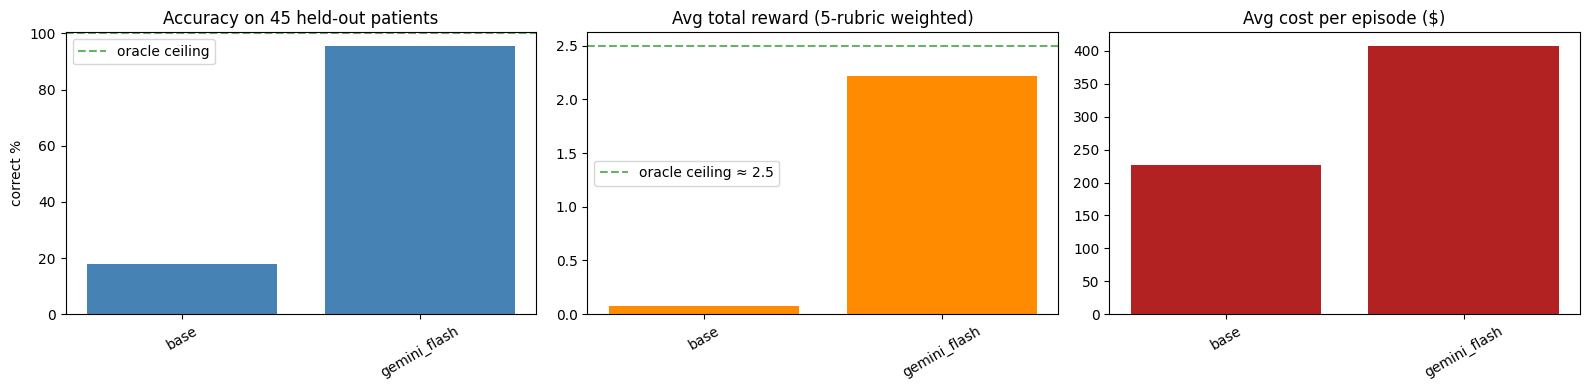

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

ORDER = ["random", "greedy", "base", "sft", "grpo", "gemini_flash"]
rows = []
for tag in ORDER:
    s = summaries.get(tag)
    if not s:
        continue
    rows.append({
        "model": tag,
        "n": s["n_evaluated"],
        "acc %": s["correct_pct"],
        "avg total": round(s["avg_rewards"]["total"], 3),
        "r1 accuracy": round(s["avg_rewards"]["r1_accuracy"], 3),
        "r2 cost": round(s["avg_rewards"]["r2_cost"], 3),
        "r7 safety": round(s["avg_rewards"]["r7_safety"], 3),
        "r8 format": round(s["avg_rewards"]["r8_format"], 3),
        "avg steps": s.get("avg_steps"),
        "avg cost ($)": s.get("avg_cost"),
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False) if not df.empty else "(no eval JSONs available)")

if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].bar(df["model"], df["acc %"], color="steelblue")
    axes[0].set_title("Accuracy on 45 held-out patients")
    axes[0].set_ylabel("correct %")
    axes[0].axhline(100, linestyle="--", color="green", alpha=0.6, label="oracle ceiling")
    axes[0].legend()
    axes[1].bar(df["model"], df["avg total"], color="darkorange")
    axes[1].set_title("Avg total reward (5-rubric weighted)")
    axes[1].axhline(2.5, linestyle="--", color="green", alpha=0.6, label="oracle ceiling ≈ 2.5")
    axes[1].legend()
    axes[2].bar(df["model"], df["avg cost ($)"], color="firebrick")
    axes[2].set_title("Avg cost per episode ($)")
    for ax in axes:
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig("eval_compare.png", dpi=120)
    plt.show()

## 11. Optional GPU — SFT mini warm-start

**Skip if you don't have a GPU.** Colab-tuned reduction of [`scripts/train_sft.py`](https://github.com/sneh2909/Overfitters/blob/main/scripts/train_sft.py): same Unsloth + TRL `SFTTrainer` recipe, same Gemma 3 chat template, same `train_on_responses_only` prompt-token masking. Differences from the canonical L4 job:

| Knob | Canonical L4 (`train_sft.py`) | This notebook (T4 16 GB) |
|---|---|---|
| `MAX_SEQ_LEN` | 4096 | 2048 |
| `BATCH_SIZE × GRAD_ACCUM` | 4 × 4 = 16 | 2 × 4 = 8 |
| Samples | All 2,151 | First `MINI_SAMPLES=200` |

Trains in ~12 min and pushes a `house-md-sft-gemma3-4b-mini` adapter to your HF account. The full production checkpoint at `SnehShah/house-md-sft-gemma3-4b` is a drop-in replacement everywhere we reference an SFT adapter.

In [2]:
import torch
RUN_SFT = torch.cuda.is_available()
print("GPU available:", RUN_SFT)
if not RUN_SFT:
    print("Skipping SFT — switch to a GPU runtime to enable.")

GPU available: False
Skipping SFT — switch to a GPU runtime to enable.


/home/sneh/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
if RUN_SFT:
    %pip install -q -U "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
    %pip install -q --no-deps "trl<0.9.0" peft accelerate bitsandbytes datasets
    %pip install -q wandb

In [4]:
if RUN_SFT:
    from datasets import load_dataset, Dataset
    from pathlib import Path
    import json

    MINI_SAMPLES = 200
    if Path("data/sft_dataset.jsonl").exists():
        rows = [json.loads(l) for l in open("data/sft_dataset.jsonl")][:MINI_SAMPLES]
        sft_ds = Dataset.from_list([{"prompt": r["prompt"], "completion": r["completion"]} for r in rows])
    else:
        # Repo holds sft_dataset.jsonl + oracle_trajectories.jsonl + eval_set.jsonl at the
        # root — HF's auto-split detection only registers eval_set.jsonl (as the `test`
        # split), so we have to point at the SFT file explicitly.
        full = load_dataset(
            "SnehShah/house-md-sft-data",
            data_files="sft_dataset.jsonl",
            split="train",
        )
        sft_ds = full.select(range(min(MINI_SAMPLES, len(full))))
    print(f"using {len(sft_ds)} samples")

## 9. Test the standard OpenEnv UI Space

Open <https://snehshah-house-md-env-openenv.hf.space/web/>, click **Reset**, then send any of the action JSONs printed below as a **Step**. The same JSON works through the OpenEnv `HouseMDAction` model in Python.

In [5]:
if RUN_SFT:
    from unsloth import FastLanguageModel, is_bfloat16_supported, train_on_responses_only
    from trl import SFTTrainer, SFTConfig

    # Hyperparameters — Colab-tuned subset of scripts/train_sft.py.
    BASE_MODEL    = "unsloth/gemma-3-4b-it-unsloth-bnb-4bit"
    SFT_HUB_ID    = f"{HF_USERNAME}/house-md-sft-gemma3-4b-mini" if HF_USERNAME else None
    NUM_EPOCHS    = 1
    BATCH_SIZE    = 2          # T4-friendly; canonical L4 uses 4
    GRAD_ACCUM    = 4          # effective batch = 8
    LR            = 2e-4
    LORA_RANK     = 16
    MAX_SEQ_LEN   = 2048       # T4-friendly; canonical L4 uses 4096

    sft_model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=MAX_SEQ_LEN,
        dtype=None,
        load_in_4bit=True,
        token=HF_TOKEN or None,
    )
    sft_model = FastLanguageModel.get_peft_model(
        sft_model,
        r=LORA_RANK,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_alpha=LORA_RANK,
        lora_dropout=0.05,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=42,
    )

    def _format_row(ex):
        msgs = [
            {"role": "user",      "content": ex["prompt"]},
            {"role": "assistant", "content": ex["completion"]},
        ]
        return {"text": tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=False,
        )}

    sft_ds_fmt = sft_ds.map(_format_row, desc="Formatting with Gemma chat template")
    sft_ds_fmt = sft_ds_fmt.remove_columns(
        [c for c in sft_ds_fmt.column_names if c != "text"]
    )

    print("\n--- Sample formatted example (first 500 chars) ---")
    print(sft_ds_fmt[0]["text"][:500])
    print("...")

    steps_per_epoch = max(1, len(sft_ds_fmt) // (BATCH_SIZE * GRAD_ACCUM))
    total_steps     = steps_per_epoch * NUM_EPOCHS
    warmup_steps    = max(10, total_steps // 10)
    logging_steps   = max(1, total_steps // 50)

    print(f"\nTraining config:")
    print(f"  samples={len(sft_ds_fmt)}, epochs={NUM_EPOCHS}")
    print(f"  effective_batch={BATCH_SIZE * GRAD_ACCUM}")
    print(f"  steps/epoch={steps_per_epoch}, total_steps={total_steps}")
    print(f"  warmup={warmup_steps}, lr={LR}, lora_rank={LORA_RANK}")

    trainer = SFTTrainer(
        model=sft_model,
        tokenizer=tokenizer,
        train_dataset=sft_ds_fmt,
        args=SFTConfig(
            num_train_epochs=NUM_EPOCHS,
            per_device_train_batch_size=BATCH_SIZE,
            gradient_accumulation_steps=GRAD_ACCUM,
            learning_rate=LR,
            warmup_steps=warmup_steps,
            lr_scheduler_type="cosine",
            fp16=not is_bfloat16_supported(),
            bf16=is_bfloat16_supported(),
            optim="adamw_8bit",
            weight_decay=0.01,
            max_grad_norm=1.0,
            dataset_text_field="text",
            max_seq_length=MAX_SEQ_LEN,
            dataset_num_proc=2,
            packing=False,
            output_dir="outputs/sft-mini",
            save_strategy="epoch",
            save_total_limit=1,
            logging_steps=logging_steps,
            report_to="wandb" if WANDB_API_KEY else "none",
            run_name="sft-gemma3-4b-house-md-mini",
            seed=42,
        ),
    )

    # Mask loss on prompt tokens — only train on the action JSON completion.
    # Same recipe as scripts/train_sft.py:build_trainer.
    trainer = train_on_responses_only(
        trainer,
        instruction_part="<start_of_turn>user\n",
        response_part="<start_of_turn>model\n",
    )

    trainer.train()
    print("Training complete.")

    sft_model.save_pretrained("outputs/sft-mini/final")
    tokenizer.save_pretrained("outputs/sft-mini/final")
    print("✓ adapter saved locally to outputs/sft-mini/final")

    if HF_TOKEN and SFT_HUB_ID:
        sft_model.push_to_hub(SFT_HUB_ID, token=HF_TOKEN)
        tokenizer.push_to_hub(SFT_HUB_ID, token=HF_TOKEN)
        print(f"✓ pushed to https://huggingface.co/{SFT_HUB_ID}")
    else:
        print("HF_USERNAME / HF_TOKEN missing — skipping Hub push.")

## 12. Optional GPU — GRPO mini loop (local in-process env)

Group-relative policy optimisation. **30 steps × group_size 4 ≈ 15 min on a T4** with a local `ClinicalEnv` (no HTTP latency). The recipe is a faithful Colab-tuned reduction of [`scripts/train_grpo_optimized.py`](https://github.com/sneh2909/Overfitters/blob/main/scripts/train_grpo_optimized.py):

| Step | Canonical recipe (used here too) |
|---|---|
| Rollouts | Local `ClinicalEnv` — `render_prompt(obs, catalogs, include_menu=False)` builds the system+intake+history prompt; the model emits one JSON action; `parse_action_json` falls back to a random INTERVIEW on parse error. |
| Reward | `clinical_rl.rewards.compute_all(episode, card, catalogs)` — same five rubrics (R1 accuracy, R2 cost, R6 anchoring, R7 safety, R8 format) the production runs use. |
| Log probs | `_compute_log_probs` — slices logits at `[n-1 : n-1+m]` and gathers per-token probabilities with a fresh `model(...)` forward pass. We deliberately **do not** use `output.scores` from `generate()` because those are temperature-scaled. |
| Loss | Fast single-update GRPO: `-advantage * mean(new_log_probs)`. Group-relative advantages with `pstdev` floored at 1e-6. Per-turn `.backward()` so we never hold a whole episode's activations on-GPU. |
| Optimizer | 8-bit `PagedAdamW` (offloads optimizer state to CPU RAM) at LR=1e-5 with grad-norm clip 0.5. |

Differences from the canonical L4/A100 job: `GROUP_SIZE=4` (not 8), `TOTAL_STEPS=30` (not 100), no curriculum or adaptive sampling, no mid-training eval/checkpoint cadence — those are knobs you'd turn back on for a real run.

In [6]:
RUN_GRPO = torch.cuda.is_available()
print("GPU available:", RUN_GRPO)
if not RUN_GRPO:
    print("Skipping GRPO — switch to a GPU runtime to enable.")

GPU available: False
Skipping GRPO — switch to a GPU runtime to enable.


In [7]:
if RUN_GRPO:
    import json, random, statistics, csv, sys
    from pathlib import Path
    import torch.nn.functional as F
    from peft import PeftModel
    from unsloth import FastLanguageModel
    import bitsandbytes as bnb

    # The pip-installed env package keeps its core engine under
    # house_md_env/clinical_rl, but uses absolute `clinical_rl.*` imports
    # internally — same trick scripts/train_grpo_optimized.py uses.
    import house_md_env
    PKG_DIR = Path(house_md_env.__file__).resolve().parent
    if str(PKG_DIR) not in sys.path:
        sys.path.insert(0, str(PKG_DIR))

    from clinical_rl.env import (
        ClinicalEnv, load_catalogs, load_cards, Action, ActionType,
    )
    from clinical_rl.prompt import render_prompt, parse_action_json
    from clinical_rl.rewards import compute_all

    DATA_DIR  = PKG_DIR / "data"
    catalogs  = load_catalogs(str(DATA_DIR))
    cards     = load_cards(str(DATA_DIR / "cards"))
    local_env = ClinicalEnv(catalogs, cards)
    print(f"✓ local ClinicalEnv ready ({len(catalogs.diseases)} diseases, "
          f"{len(catalogs.questions)} questions, {len(catalogs.tests)} tests)")

    # ── Hyperparameters (Colab-tuned subset of train_grpo_optimized.py) ──
    BASE_MODEL    = "unsloth/gemma-3-4b-it-unsloth-bnb-4bit"
    SFT_ADAPTER   = os.environ.get("SFT_ADAPTER", "SnehShah/house-md-sft-gemma3-4b")
    GRPO_HUB_ID   = f"{HF_USERNAME}/house-md-grpo-gemma3-4b-mini" if HF_USERNAME else None
    TOTAL_STEPS   = int(os.environ.get("TOTAL_STEPS", "30"))
    GROUP_SIZE    = int(os.environ.get("GROUP_SIZE", "4"))
    TEMPERATURE   = 0.9
    LR            = 1e-5
    GRAD_CLIP     = 0.5
    MAX_NEW_TOK   = 150
    INCLUDE_MENU  = False
    DEVICE        = "cuda"
    LEVEL_1       = ["ectopic_pregnancy", "stemi", "appendicitis", "migraine", "viral_uri"]

    grpo_model, grpo_tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=4096,
        dtype=None,
        load_in_4bit=True,
        token=HF_TOKEN or None,
    )
    try:
        grpo_model = PeftModel.from_pretrained(
            grpo_model, SFT_ADAPTER, is_trainable=True, token=HF_TOKEN or None,
        )
        print(f"✓ loaded SFT adapter: {SFT_ADAPTER}")
    except Exception as e:
        print(f"⚠  could not load SFT adapter ({e}); using fresh LoRA")
        grpo_model = FastLanguageModel.get_peft_model(
            grpo_model, r=16,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                            "gate_proj", "up_proj", "down_proj"],
            lora_alpha=16, lora_dropout=0.05, bias="none",
            use_gradient_checkpointing="unsloth", random_state=42,
        )
    grpo_model.train()

    # PagedAdamW8bit — same optimizer scripts/train_grpo_optimized.py uses.
    optim = bnb.optim.PagedAdamW8bit(
        [p for p in grpo_model.parameters() if p.requires_grad],
        lr=LR, weight_decay=0.01,
    )

    if WANDB_API_KEY:
        import wandb
        wandb.init(
            project="house-md",
            name=f"grpo-colab-mini-{TOTAL_STEPS}steps",
            config={"steps": TOTAL_STEPS, "group_size": GROUP_SIZE,
                    "lr": LR, "temperature": TEMPERATURE,
                    "include_menu": INCLUDE_MENU},
        )
    print(f"✓ ready for GRPO ({GROUP_SIZE} rollouts × {TOTAL_STEPS} steps)")

In [8]:
if RUN_GRPO:
    # ── Helpers — mirror scripts/train_grpo_optimized.py exactly ─────────────

    def _compute_log_probs(model, prompt_ids, action_ids, requires_grad=True):
        """Per-token log-probs of action_ids given prompt_ids.

        Slicing: the logits at position `i` predict token `i+1`, so we want
        logits[n-1 : n-1+m] to predict the m action tokens. We deliberately do
        NOT use generate()'s output.scores because those are temperature-scaled.
        """
        full_ids = torch.cat([prompt_ids, action_ids]).unsqueeze(0).to(DEVICE)
        if requires_grad:
            logits = model(full_ids).logits[0].float()
        else:
            with torch.inference_mode():
                logits = model(full_ids).logits[0].float()
        n, m = prompt_ids.shape[0], action_ids.shape[0]
        action_logits = logits[n - 1 : n - 1 + m]
        log_probs     = F.log_softmax(action_logits, dim=-1)
        return log_probs.gather(
            dim=1, index=action_ids.to(DEVICE).unsqueeze(1),
        ).squeeze(1)

    def _parse_or_fallback(text, rng):
        """Same fallback policy the production script uses: a random INTERVIEW
        is a safe no-op (free, doesn't terminate the episode), and R8 will
        penalise the format error so the model is pushed back toward valid JSON."""
        for _ in range(3):
            try:
                return parse_action_json(text)
            except ValueError:
                pass
        qid = rng.choice(list(catalogs.questions.keys()))
        return Action(ActionType.INTERVIEW, qid, "fallback - parse error")

    def play_episode(disease, variant_id, seed, rng):
        """One full episode. Returns (turns, episode) where turns is a list of
        (prompt_ids_cpu, action_ids_cpu) — used later for the loss pass."""
        obs = local_env.reset(disease, variant_id=variant_id, seed=seed)
        turns = []
        while not obs.terminal:
            prompt_text = render_prompt(obs, catalogs, include_menu=INCLUDE_MENU)
            messages = [{"role": "user",
                         "content": [{"type": "text", "text": prompt_text}]}]
            prompt_ids = grpo_tokenizer.apply_chat_template(
                messages, tokenize=True, return_tensors="pt",
                add_generation_prompt=True,
            )[0].cpu()
            with torch.inference_mode():
                output = grpo_model.generate(
                    prompt_ids.unsqueeze(0).to(DEVICE),
                    max_new_tokens=MAX_NEW_TOK, temperature=TEMPERATURE,
                    do_sample=True, pad_token_id=grpo_tokenizer.eos_token_id,
                )
            action_ids = output[0][prompt_ids.shape[0]:].cpu()
            text   = grpo_tokenizer.decode(action_ids, skip_special_tokens=True)
            action = _parse_or_fallback(text, rng)
            turns.append((prompt_ids, action_ids))
            obs = local_env.step(action)
        return turns, local_env._episode

    def compute_grpo_loss(rollouts, advantages):
        """Fast single-update GRPO loss: -A_i * mean(new_log_prob_t).
        Per-turn .backward() so peak GPU memory stays low."""
        total_loss, terms = 0.0, 0
        for (turns, _), advantage in zip(rollouts, advantages):
            for prompt_ids, action_ids in turns:
                if action_ids.shape[0] == 0:
                    continue
                new_lp = _compute_log_probs(
                    grpo_model, prompt_ids, action_ids, requires_grad=True,
                )
                adv = torch.tensor(advantage, device=DEVICE, dtype=torch.float32)
                turn_loss = -(adv * new_lp.mean())
                total_loss += turn_loss.detach().item()
                terms += 1
                # Divide by GROUP_SIZE so accumulated grad is a group average.
                (turn_loss / GROUP_SIZE).backward()
        return total_loss / max(terms, 1)

    # ── Smoke test: verify slicing + grad flow BEFORE burning compute ────────
    _smoke_msgs = [{"role": "user",
                    "content": [{"type": "text", "text": "Smoke test."}]}]
    _smoke_prompt = grpo_tokenizer.apply_chat_template(
        _smoke_msgs, tokenize=True, return_tensors="pt",
        add_generation_prompt=True,
    )[0].cpu()
    with torch.inference_mode():
        _smoke_out = grpo_model.generate(
            _smoke_prompt.unsqueeze(0).to(DEVICE), max_new_tokens=8,
            do_sample=False, pad_token_id=grpo_tokenizer.eos_token_id,
        )
    _smoke_act = _smoke_out[0][_smoke_prompt.shape[0]:].cpu()
    if _smoke_act.shape[0] > 0:
        _lp = _compute_log_probs(
            grpo_model, _smoke_prompt, _smoke_act, requires_grad=False,
        )
        assert _lp.shape == _smoke_act.shape and (_lp <= 0).all()
        print(f"✓ smoke test PASSED — log_probs.shape={tuple(_lp.shape)} "
              f"mean={_lp.mean():.3f}")

    # ── Training loop ────────────────────────────────────────────────────────
    log_path = Path("reward_log.csv")
    if log_path.exists():
        log_path.unlink()
    with log_path.open("w", newline="") as fh:
        csv.writer(fh).writerow(
            ["step", "disease", "mean_r", "std_r", "max_r", "loss"]
        )

    rng     = random.Random(42)
    history = []
    for step in range(1, TOTAL_STEPS + 1):
        disease    = rng.choice(LEVEL_1)
        variant_id = rng.choice(["v1", "v2", "v3"])
        seed       = rng.randint(1000, 999_999)

        # Phase 1 — rollout the same patient GROUP_SIZE times (no grad).
        rollouts = []
        for _ in range(GROUP_SIZE):
            turns, episode = play_episode(disease, variant_id, seed, rng)
            reward = compute_all(episode, cards[disease], catalogs)["total"]
            rollouts.append((turns, reward))

        # Phase 2 — group-relative advantages (pstdev floored at 1e-6).
        rewards    = [r for _, r in rollouts]
        mean_r     = statistics.mean(rewards)
        std_r      = max(statistics.pstdev(rewards), 1e-6)
        advantages = [(r - mean_r) / std_r for r in rewards]

        # Phase 3 — loss + gradient step.
        optim.zero_grad()
        mean_loss = compute_grpo_loss(rollouts, advantages)
        torch.nn.utils.clip_grad_norm_(
            [p for p in grpo_model.parameters() if p.requires_grad], GRAD_CLIP,
        )
        optim.step()

        max_r = max(rewards)
        history.append({"step": step, "disease": disease,
                        "mean_r": mean_r, "max_r": max_r, "loss": mean_loss})
        with log_path.open("a", newline="") as fh:
            csv.writer(fh).writerow([
                step, disease, f"{mean_r:.4f}", f"{std_r:.4f}",
                f"{max_r:.4f}", f"{mean_loss:.4f}",
            ])
        if WANDB_API_KEY:
            wandb.log({
                "grpo/mean_reward": mean_r, "grpo/max_reward": max_r,
                "grpo/std": std_r, "grpo/loss": mean_loss, "step": step,
            })
        print(
            f"step {step:>3}/{TOTAL_STEPS}  disease={disease:<22} "
            f"r_mean={mean_r:+.3f}  r_std={std_r:.3f}  loss={mean_loss:+.4f}"
        )

    grpo_model.save_pretrained("outputs/grpo-mini/final")
    grpo_tokenizer.save_pretrained("outputs/grpo-mini/final")
    print("✓ adapter saved locally to outputs/grpo-mini/final")

    if HF_TOKEN and GRPO_HUB_ID:
        grpo_model.push_to_hub(GRPO_HUB_ID, token=HF_TOKEN)
        grpo_tokenizer.push_to_hub(GRPO_HUB_ID, token=HF_TOKEN)
        print(f"✓ pushed to https://huggingface.co/{GRPO_HUB_ID}")
    else:
        print("HF_USERNAME / HF_TOKEN missing — skipping Hub push.")

    if WANDB_API_KEY:
        wandb.finish()

In [9]:
if RUN_GRPO and history:
    import pandas as pd
    import matplotlib.pyplot as plt
    df_grpo = pd.DataFrame(history)
    df_grpo["mean_r_smooth"] = df_grpo["mean_r"].rolling(5, min_periods=1).mean()
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(df_grpo["step"], df_grpo["mean_r"], alpha=0.4, label="per-step mean")
    ax.plot(df_grpo["step"], df_grpo["mean_r_smooth"], linewidth=2, label="5-step rolling mean")
    ax.axhline(y=2.5, linestyle="--", color="green", label="oracle ceiling ≈ 2.5")
    ax.set_xlabel("GRPO step")
    ax.set_ylabel("group mean reward")
    ax.set_title("GRPO mini reward curve")
    ax.legend()
    plt.tight_layout()
    plt.savefig("grpo_reward_curve.png", dpi=120)
    plt.show()

## 13. Optional GPU — local mini-eval of any adapter

Run any LoRA adapter for `N_PATIENTS` patients against a local in-process `ClinicalEnv`, using the held-out seeds in `data/eval_set.jsonl` (the same set [`scripts/eval_hf.py`](https://github.com/sneh2909/Overfitters/blob/main/scripts/eval_hf.py) uses for the production benchmark numbers). Greedy decoding for reproducibility. Set `ADAPTER_PATH = ""` to evaluate the **base** Gemma 3 4B-IT directly.

In [10]:
if torch.cuda.is_available():
    import json, sys
    from pathlib import Path
    from unsloth import FastLanguageModel
    from peft import PeftModel
    import house_md_env

    PKG_DIR = Path(house_md_env.__file__).resolve().parent
    if str(PKG_DIR) not in sys.path:
        sys.path.insert(0, str(PKG_DIR))
    from clinical_rl.env import ClinicalEnv, load_catalogs, load_cards, Action, ActionType
    from clinical_rl.prompt import render_prompt, parse_action_json
    from clinical_rl.rewards import compute_all

    ADAPTER_PATH = "SnehShah/house-md-grpo-optimized-gemma3-4b-v3"
    N_PATIENTS   = 6
    INCLUDE_MENU = False
    MAX_NEW_TOK  = 150

    eval_model, eval_tok = FastLanguageModel.from_pretrained(
        model_name="unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
        max_seq_length=4096, dtype=None, load_in_4bit=True,
        token=HF_TOKEN or None,
    )
    if ADAPTER_PATH:
        eval_model = PeftModel.from_pretrained(
            eval_model, ADAPTER_PATH, token=HF_TOKEN or None,
        )
    FastLanguageModel.for_inference(eval_model)

    DATA_DIR  = PKG_DIR / "data"
    cat       = load_catalogs(str(DATA_DIR))
    cards_eval = load_cards(str(DATA_DIR / "cards"))
    eval_env  = ClinicalEnv(cat, cards_eval)

    eval_records = [
        json.loads(l) for l in open(DATA_DIR / "eval_set.jsonl")
    ][:N_PATIENTS]

    correct = 0
    total_r = 0.0
    for i, rec in enumerate(eval_records):
        disease    = rec["disease"]
        variant_id = rec["variant_id"]
        seed       = rec["seed"]
        obs = eval_env.reset(disease, variant_id=variant_id, seed=seed)
        while not obs.terminal:
            prompt = render_prompt(obs, cat, include_menu=INCLUDE_MENU)
            inputs = eval_tok.apply_chat_template(
                [{"role": "user",
                  "content": [{"type": "text", "text": prompt}]}],
                return_tensors="pt", add_generation_prompt=True,
            ).to(eval_model.device)
            with torch.inference_mode():
                out = eval_model.generate(
                    inputs, max_new_tokens=MAX_NEW_TOK,
                    do_sample=False,                        # greedy for repro
                    pad_token_id=eval_tok.eos_token_id,
                )
            text = eval_tok.decode(
                out[0][inputs.shape[-1]:], skip_special_tokens=True,
            )
            try:
                action = parse_action_json(text)
            except ValueError:
                action = Action(ActionType.DIAGNOSE, "viral_uri", "fallback")
            obs = eval_env.step(action)

        episode = eval_env._episode
        rewards = compute_all(episode, cards_eval[disease], cat)
        guess   = episode.obs.diagnosis
        ok      = (guess == disease)
        correct += int(ok)
        total_r += rewards["total"]
        print(
            f"[{i+1}/{N_PATIENTS}] truth={disease:<22} "
            f"guess={str(guess):<22} reward={rewards['total']:+.2f} "
            f"{'✓' if ok else '✗'}"
        )

    label = ADAPTER_PATH or "base"
    print(
        f"\nLocal mini-eval ({label}): "
        f"{correct}/{N_PATIENTS} correct  "
        f"avg total reward {total_r/N_PATIENTS:+.3f}"
    )
else:
    print("No GPU — skipping local mini-eval.")

No GPU — skipping local mini-eval.


## 14. Cleanup

Free the OpenEnv session on the Space.

In [11]:
try:
    env.close()
    print("✓ closed OpenEnv session")
except Exception as e:
    print("close error:", e)

close error: name 'env' is not defined
